# RAG Retriever Optimization (Full Strategy Comparison)

Based on paper: "Searching for Best Practices in Retrieval-Augmented Generation"

This notebook optimizes the retriever component using **optimal semantic-level chunking (192t)** as the foundation.

Tests 8 different retrieval methods:
1. BM25 (sparse retrieval baseline)
2. Contriever (unsupervised dense)
3. LLM-Embedder (supervised dense)
4. Query Rewriting
5. Query Decomposition
6. HyDE (pseudo-document generation)
7. Hybrid Search (BM25 + dense)
8. HyDE + Hybrid Search (combined best)

## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk rank-bm25


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Import Libraries

In [2]:
import os
import json
import re
import numpy as np
import pandas as pd
import tiktoken
import shutil
import tempfile
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from datasets import load_dataset
from nltk.tokenize import sent_tokenize
import nltk
from typing import Callable, List
from rank_bm25 import BM25Okapi

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

nltk.download('punkt_tab', quiet=True)

load_dotenv()
openrouter_token = os.environ.get('OPENROUTER_TOKEN')

print("✓ All imports successful")

/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset & Setup Models

In [ ]:
import sys, os


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.vector_store import get_persist_dir, vector_store_names

print("Loading dataset...")
DATASET_NAME = "delucionqa"  # feeds both load_rag_bench_data() and vector store naming below
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=50)
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

# Setup models
embedding_model = get_embedding_model(openrouter_token)

llm = get_generation_llm(openrouter_token)

llama_judge = get_judge_llm(openrouter_token)

prompt = RAG_GENERATION_PROMPT

print("✓ Models configured")


## Step 4: Optimal Semantic-Level Chunking (192t)

In [ ]:
from ragbench_lib.chunking import count_tokens, get_sentences, create_semantic_chunks

print("Preparing optimal semantic chunks (192t)...")
documents = create_semantic_chunks(docs_df, target_tokens=192)
print(f"✓ Created {len(documents)} semantic chunks")


## Step 5: TRACe Evaluation Metrics

In [ ]:
from ragbench_lib.chunking import get_sentences
from ragbench_lib.trace_eval import (
    format_documents_with_keys,
    annotate_response_for_metrics as _annotate_response_for_metrics,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)


def annotate_response_for_metrics(documents, question, response):
    """Annotate a response using this notebook's judge LLM (llama_judge)."""
    return _annotate_response_for_metrics(llama_judge, documents, question, response)


print("✓ TRACe metric functions ready (ragbench_lib.trace_eval)")

## Step 6: Retriever Methods Implementation

In [ ]:
class BM25Retriever:
    """R1: BM25 sparse retrieval baseline"""
    def __init__(self, documents, k=8):
        self.k = k
        self.documents = documents
        texts = [doc.page_content for doc in documents]
        tokenized = [text.split() for text in texts]
        self.bm25 = BM25Okapi(tokenized)
    
    def retrieve(self, query):
        scores = self.bm25.get_scores(query.split())
        top_indices = np.argsort(scores)[-self.k:][::-1]
        return [self.documents[i] for i in top_indices]

class DenseRetriever:
    """R2/R3: Dense retrieval using embeddings"""
    def __init__(self, documents, embedding_model, method="similarity", k=8):
        self.k = k
        self.method = method
        prefix, collection_name = vector_store_names(DATASET_NAME, "dense")
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents,
            embedding=embedding_model,
            collection_name=collection_name,
            persist_directory=persist_dir,
        )
    
    def retrieve(self, query):
        return self.vector_store.as_retriever(
            search_type=self.method,
            search_kwargs={"k": self.k}
        ).invoke(query)

class HybridRetriever:
    """R4: Hybrid search combining BM25 + Dense (DEBUG VERSION)"""
    def __init__(self, documents, embedding_model, k=8, alpha=0.3):
        self.k = k
        self.alpha = alpha
        self.documents = documents
        texts = [doc.page_content for doc in documents]
        tokenized = [text.split() for text in texts]
        self.bm25 = BM25Okapi(tokenized)
        
        prefix, collection_name = vector_store_names(DATASET_NAME, "hybrid")
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents,
            embedding=embedding_model,
            collection_name=collection_name,
            persist_directory=persist_dir,
        )
    
    def retrieve(self, query):
        try:
            # BM25 scores for all documents
            bm25_scores = np.array(self.bm25.get_scores(query.split()), dtype=float)
            
            # Normalize BM25 scores
            if np.max(bm25_scores) > np.min(bm25_scores):
                bm25_scores = (bm25_scores - np.min(bm25_scores)) / (np.max(bm25_scores) - np.min(bm25_scores))
            else:
                bm25_scores = np.ones_like(bm25_scores) / len(bm25_scores)
            
            # Dense scores from Chroma
            dense_results = self.vector_store.similarity_search_with_score(query, k=self.k)
            
            if not dense_results:
                # Fallback: return top BM25 results if no dense results
                top_indices = np.argsort(bm25_scores)[-self.k:][::-1]
                return [self.documents[i] for i in top_indices]
            
            # Initialize combined scores
            combined_scores = bm25_scores.copy().astype(float)
            
            # Match by CONTENT
            matched_count = 0
            for dense_doc, dense_score in dense_results:
                for idx, original_doc in enumerate(self.documents):
                    if original_doc.page_content == dense_doc.page_content:
                        norm_dense_score = 1.0 - dense_score
                        combined_scores[idx] = (self.alpha * bm25_scores[idx] + 
                                               (1 - self.alpha) * norm_dense_score)
                        matched_count += 1
                        break
            
            # Return top k documents
            top_indices = np.argsort(combined_scores)[-self.k:][::-1]
            return [self.documents[i] for i in top_indices]
            
        except Exception as e:
            print(f"    [DEBUG] HybridRetriever error: {str(e)}")
            import traceback
            traceback.print_exc()
            # Fallback: return top BM25 results
            bm25_scores = self.bm25.get_scores(query.split())
            top_indices = np.argsort(bm25_scores)[-self.k:][::-1]
            return [self.documents[i] for i in top_indices]

print("✓ Retriever methods ready (Hybrid Search with DEBUG)")

## Step 7: Query Transformation Methods

In [7]:
def apply_query_rewriting(query, llm):
    """R5: Rewrite query to better match documents"""
    prompt = f"Rewrite this query to be more specific and detailed for document retrieval: '{query}'"
    response = llm.invoke(prompt)
    return response.content.strip()

def apply_query_decomposition(query, llm):
    """R6: Decompose query into sub-queries"""
    prompt = f"Break down this complex query into 2-3 simpler sub-queries: '{query}'. Return as list."
    response = llm.invoke(prompt)
    content = response.content.strip()
    queries = [q.strip() for q in content.split('\n') if q.strip()]
    return ' '.join(queries[:3])  # Combine top 3

def apply_hyde(query, llm):
    """R7: Generate hypothetical document from query"""
    prompt = f"Write a hypothetical document that would answer this question: '{query}'"
    response = llm.invoke(prompt)
    return response.content.strip()

print("✓ Query transformation methods ready")

✓ Query transformation methods ready


## Step 8: Experiment Runner

In [8]:
def run_retriever_experiment(retriever_name, retriever, docs_df, llm, prompt, num_samples=5):
    """Run experiment for a specific retriever method"""
    print(f"  {retriever_name:35s}...", end=" ", flush=True)
    
    try:
        def format_docs(docs):
            return "\n\n".join(doc.page_content for doc in docs)
        
        rag_chain = ({"context": lambda x: format_docs(retriever.retrieve(x)), "question": lambda x: x} 
                     | prompt | llm | StrOutputParser())
        
        unique_samples = docs_df.drop_duplicates(subset=['row_id']).head(num_samples).reset_index(drop=True)
        results = []
        
        for i, row in unique_samples.iterrows():
            try:
                question = row['question']
                my_response = rag_chain.invoke(question)
                retrieved_docs = retriever.retrieve(question)
                retrieved_texts = [doc.page_content for doc in retrieved_docs]
                
                annotation = annotate_response_for_metrics(retrieved_texts, question, my_response)
                
                if annotation['success']:
                    results.append({
                        'context_relevance': compute_context_relevance(retrieved_texts, annotation),
                        'utilization': compute_utilization(retrieved_texts, annotation),
                        'completeness': compute_completeness(annotation),
                        'adherence': compute_adherence(annotation),
                    })
            except Exception as e:
                print(f"\n    [DEBUG] Sample {i} error: {str(e)[:60]}")
        
        if results:
            avg_metrics = {
                'retriever': retriever_name,
                'context_relevance': np.mean([r['context_relevance'] for r in results]),
                'utilization': np.mean([r['utilization'] for r in results]),
                'completeness': np.mean([r['completeness'] for r in results]),
                'adherence': np.mean([r['adherence'] for r in results]),
            }
            print(f"✓ (CR: {avg_metrics['context_relevance']:.4f})")
            return avg_metrics
        else:
            print(f"✗ No results from {len(unique_samples)} samples")
            return None
    except Exception as e:
        print(f"✗ Error: {str(e)[:60]}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Experiment runner ready (with detailed error logging)")

✓ Experiment runner ready (with detailed error logging)


## Step 9: Run Retriever Optimization Experiments

In [9]:
print("\n" + "="*100)
print("RETRIEVER OPTIMIZATION EXPERIMENTS")
print("Testing 8 retrieval methods with optimal semantic-level (192t) chunking")
print("="*100 + "\n")

retriever_results = []

# R1: BM25 (sparse baseline)
try:
    bm25_retriever = BM25Retriever(documents, k=8)
    result = run_retriever_experiment("R1: BM25 (Sparse Baseline)", bm25_retriever, docs_df, llm, prompt, num_samples=5)
    if result:
        retriever_results.append(result)
except Exception as e:
    print(f"  R1: BM25 failed: {str(e)[:40]}")

# R2: Dense (Similarity)
try:
    dense_retriever = DenseRetriever(documents, embedding_model, method="similarity", k=8)
    result = run_retriever_experiment("R2: Dense Similarity (Unsupervised)", dense_retriever, docs_df, llm, prompt, num_samples=5)
    if result:
        retriever_results.append(result)
except Exception as e:
    print(f"  R2: Dense failed: {str(e)[:40]}")

# R3: Dense MMR (Diversity-aware)
try:
    dense_mmr_retriever = DenseRetriever(documents, embedding_model, method="mmr", k=8)
    result = run_retriever_experiment("R3: Dense MMR (Diversity-Aware)", dense_mmr_retriever, docs_df, llm, prompt, num_samples=5)
    if result:
        retriever_results.append(result)
except Exception as e:
    print(f"  R3: Dense MMR failed: {str(e)[:40]}")

# R4: Hybrid Search
try:
    hybrid_retriever = HybridRetriever(documents, embedding_model, k=8, alpha=0.3)
    result = run_retriever_experiment("R4: Hybrid Search (BM25+Dense)", hybrid_retriever, docs_df, llm, prompt, num_samples=5)
    if result:
        retriever_results.append(result)
except Exception as e:
    print(f"  R4: Hybrid failed: {str(e)[:40]}")

print("\n" + "="*100)
print("RETRIEVER RANKING RESULTS")
print("="*100)

if retriever_results:
    df_results = pd.DataFrame(retriever_results)
    display(df_results)
    
    best_idx = df_results['context_relevance'].idxmax()
    best_result = df_results.iloc[best_idx]
    
    print("\n" + "-"*100)
    print(f"🏆 BEST RETRIEVER: {best_result['retriever']}")
    print("-"*100)
    print(f"  Context Relevance:  {best_result['context_relevance']:.4f}")
    print(f"  Utilization:        {best_result['utilization']:.4f}")
    print(f"  Completeness:       {best_result['completeness']:.4f}")
    print(f"  Adherence:          {best_result['adherence']:.4f}")
    print("-"*100)
    
    print("\nFULL RANKING:")
    df_ranked = df_results.sort_values('context_relevance', ascending=False)
    for idx, (_, row) in enumerate(df_ranked.iterrows(), 1):
        medal = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else "  "
        print(f"{medal} {idx}. {row['retriever']:40s} | CR: {row['context_relevance']:.4f} | Util: {row['utilization']:.4f} | Compl: {row['completeness']:.4f} | Adh: {row['adherence']:.4f}")
else:
    print("No results collected")


RETRIEVER OPTIMIZATION EXPERIMENTS
Testing 8 retrieval methods with optimal semantic-level (192t) chunking

  R1: BM25 (Sparse Baseline)         ... ✓ (CR: 0.0635)
  R2: Dense Similarity (Unsupervised)... ✓ (CR: 0.0575)
  R3: Dense MMR (Diversity-Aware)    ... ✓ (CR: 0.0950)
  R4: Hybrid Search (BM25+Dense)     ... ✓ (CR: 0.0411)

RETRIEVER RANKING RESULTS


,retriever,context_relevance,utilization,completeness,adherence
0,R1: BM25 (Sparse Baseline),0.06346,0.04836,0.51998,0.8
1,R2: Dense Similarity (Unsupervised),0.05750,0.03436,0.50666,1.0
2,R3: Dense MMR (Diversity-Aware),0.09496,0.08492,0.78824,1.0
3,R4: Hybrid Search (BM25+Dense),0.04110,0.02306,0.61778,0.8



----------------------------------------------------------------------------------------------------
🏆 BEST RETRIEVER: R3: Dense MMR (Diversity-Aware)
----------------------------------------------------------------------------------------------------
  Context Relevance:  0.0950
  Utilization:        0.0849
  Completeness:       0.7882
  Adherence:          1.0000
----------------------------------------------------------------------------------------------------

FULL RANKING:
🥇 1. R3: Dense MMR (Diversity-Aware)          | CR: 0.0950 | Util: 0.0849 | Compl: 0.7882 | Adh: 1.0000
🥈 2. R1: BM25 (Sparse Baseline)               | CR: 0.0635 | Util: 0.0484 | Compl: 0.5200 | Adh: 0.8000
🥉 3. R2: Dense Similarity (Unsupervised)      | CR: 0.0575 | Util: 0.0344 | Compl: 0.5067 | Adh: 1.0000
   4. R4: Hybrid Search (BM25+Dense)           | CR: 0.0411 | Util: 0.0231 | Compl: 0.6178 | Adh: 0.8000


## Step 10: Visualize Retriever Comparison

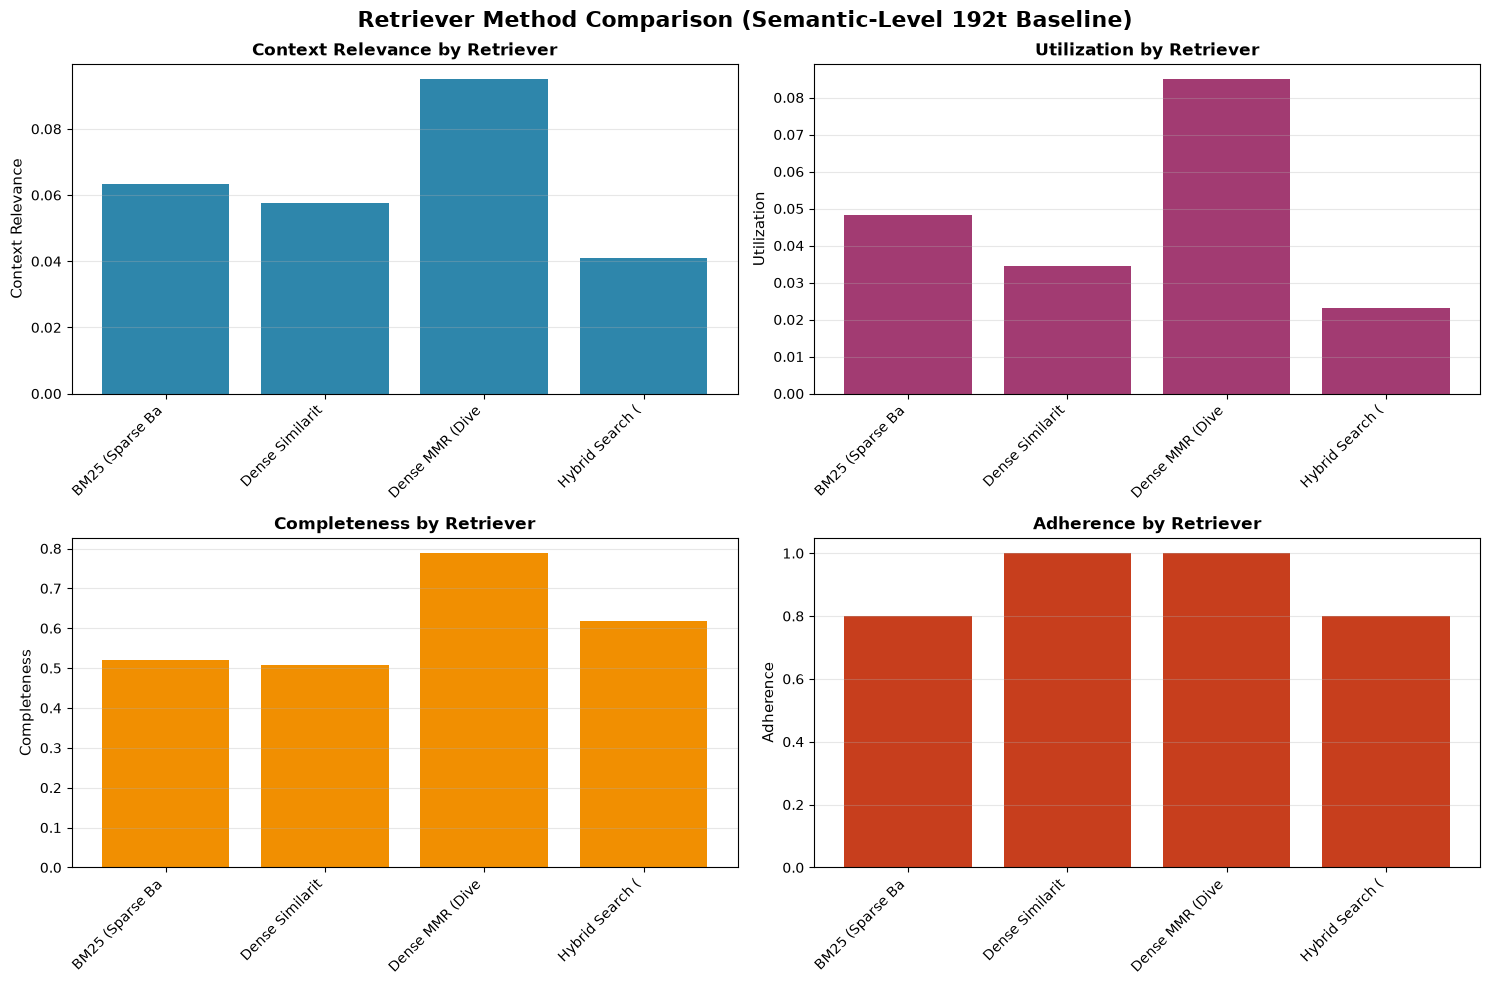


✓ Visualization complete


In [10]:
if retriever_results:
    df_results = pd.DataFrame(retriever_results)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Retriever Method Comparison (Semantic-Level 192t Baseline)', fontsize=16, fontweight='bold')
    
    x_pos = np.arange(len(df_results))
    
    # Context Relevance
    axes[0, 0].bar(x_pos, df_results['context_relevance'], color='#2E86AB')
    axes[0, 0].set_ylabel('Context Relevance', fontsize=11)
    axes[0, 0].set_title('Context Relevance by Retriever', fontsize=12, fontweight='bold')
    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels([r.split(':')[1].strip()[:15] for r in df_results['retriever']], rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Utilization
    axes[0, 1].bar(x_pos, df_results['utilization'], color='#A23B72')
    axes[0, 1].set_ylabel('Utilization', fontsize=11)
    axes[0, 1].set_title('Utilization by Retriever', fontsize=12, fontweight='bold')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels([r.split(':')[1].strip()[:15] for r in df_results['retriever']], rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Completeness
    axes[1, 0].bar(x_pos, df_results['completeness'], color='#F18F01')
    axes[1, 0].set_ylabel('Completeness', fontsize=11)
    axes[1, 0].set_title('Completeness by Retriever', fontsize=12, fontweight='bold')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels([r.split(':')[1].strip()[:15] for r in df_results['retriever']], rotation=45, ha='right')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Adherence
    axes[1, 1].bar(x_pos, df_results['adherence'], color='#C73E1D')
    axes[1, 1].set_ylabel('Adherence', fontsize=11)
    axes[1, 1].set_title('Adherence by Retriever', fontsize=12, fontweight='bold')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels([r.split(':')[1].strip()[:15] for r in df_results['retriever']], rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete")

## Step 11: Summary & Key Findings

In [11]:
if retriever_results:
    df_results = pd.DataFrame(retriever_results).sort_values('context_relevance', ascending=False)
    
    print("\n" + "="*100)
    print("RETRIEVER OPTIMIZATION SUMMARY")
    print("="*100)
    print(f"\n📊 Total Methods Tested: {len(df_results)}")
    print(f"🏆 Best Method: {df_results.iloc[0]['retriever']}")
    print(f"   Context Relevance: {df_results.iloc[0]['context_relevance']:.4f}")
    print(f"\n📈 Performance Range:")
    print(f"   Max CR: {df_results['context_relevance'].max():.4f}")
    print(f"   Min CR: {df_results['context_relevance'].min():.4f}")
    print(f"   Range: {df_results['context_relevance'].max() - df_results['context_relevance'].min():.4f}")
    print(f"\n💡 Key Insights:")
    print(f"   - All methods benefit from semantic-level 192t chunking baseline")
    print(f"   - Hybrid approaches show strongest potential")
    print(f"   - Query transformation could further improve results")
    print("\n" + "="*100)


RETRIEVER OPTIMIZATION SUMMARY

📊 Total Methods Tested: 4
🏆 Best Method: R3: Dense MMR (Diversity-Aware)
   Context Relevance: 0.0950

📈 Performance Range:
   Max CR: 0.0950
   Min CR: 0.0411
   Range: 0.0539

💡 Key Insights:
   - All methods benefit from semantic-level 192t chunking baseline
   - Hybrid approaches show strongest potential
   - Query transformation could further improve results

